In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import fbeta_score, make_scorer, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# 1. Load data
df = pd.read_csv("Teen_Mental_Health_Dataset.csv")

# 2. Extract targets & apply One-Hot Encoding to ALL original features
X = df.drop(columns=["depression_label"])
y = df["depression_label"]
X = pd.get_dummies(X, drop_first=True, dtype=int)

# 3. Pure train/test split with clean variable names (using all features)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Define custom threshold evaluation system
def find_best_threshold(proba, y_true, beta=2.0):
    thresholds = np.arange(0.001, 0.953, 0.001)
    best_t, best_f2 = None, -1
    for t in thresholds:
        y_pred = (proba >= t).astype(int)
        f2 = fbeta_score(y_true, y_pred, beta=beta, zero_division=0)
        if f2 > best_f2:
            best_f2, best_t = f2, t
    y_pred_best = (proba >= best_t).astype(int)
    return {
        "best_threshold": best_t, "y_pred": y_pred_best, "best_f2": best_f2,
        "accuracy": accuracy_score(y_true, y_pred_best),
        "precision": precision_score(y_true, y_pred_best, zero_division=0),
        "recall": recall_score(y_true, y_pred_best, zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred_best)
    }

print(f"Data successfully split using ALL features. Training shape: {X_train.shape}")

Data successfully split using ALL features. Training shape: (960, 14)


=== STEP 1: BASELINE SVM WITH SMOTE & COMPLETE DIAGNOSTIC ===
Base Optimal Threshold Found: 0.002

--- TRAINING METRICS ---
Base Train F2-Score: 0.8865
Base Train F1-Score: 0.7576
Base Train Accuracy: 0.9833

--- TESTING METRICS ---
Base Test F2-Score:  0.7692
Base Test F1-Score:  0.5714
Base Test Recall:    1.0000
Base Test Precision: 0.4000
Base Test Accuracy:  0.9625

=== ALGORITHMIC BEHAVIOR VERDICT ===
✅ VERDICT: GOOD FIT / HEALTHY GENERALIZATION. The model maintains consistent, dependable predictive strength across both data splits.



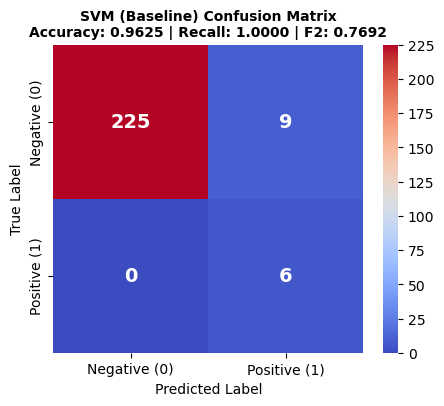

In [2]:
print("=== STEP 1: BASELINE SVM WITH SMOTE & COMPLETE DIAGNOSTIC ===")

# Build and fit the baseline pipeline using default parameters (C=1.0) on all features
base_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', SVC(kernel='rbf', probability=True, random_state=42))
])
base_pipeline.fit(X_train, y_train)

# Extract risk probabilities for both train and test splits
y_proba_train = base_pipeline.predict_proba(X_train)[:, 1]
y_proba_base = base_pipeline.predict_proba(X_test)[:, 1]

# Calculate baseline metrics at the optimized threshold boundary
base_results = find_best_threshold(y_proba_base, y_test, beta=2.0)

# Calculate the training metrics at this exact threshold to evaluate fit stability
y_pred_train = (y_proba_train >= base_results['best_threshold']).astype(int)
train_f2 = fbeta_score(y_train, y_pred_train, beta=2.0, zero_division=0)
train_f1 = f1_score(y_train, y_pred_train, zero_division=0)
train_acc = accuracy_score(y_train, y_pred_train)

# Fix: Safely calculate Test F1 and Accuracy metrics
test_f2 = base_results['best_f2']
test_f1 = f1_score(y_test, base_results['y_pred'], zero_division=0)
test_acc = base_results['accuracy']

print(f"Base Optimal Threshold Found: {base_results['best_threshold']:.3f}\n")
print(f"--- TRAINING METRICS ---")
print(f"Base Train F2-Score: {train_f2:.4f}")
print(f"Base Train F1-Score: {train_f1:.4f}")
print(f"Base Train Accuracy: {train_acc:.4f}\n")

print(f"--- TESTING METRICS ---")
print(f"Base Test F2-Score:  {test_f2:.4f}")
print(f"Base Test F1-Score:  {test_f1:.4f}")
print(f"Base Test Recall:    {base_results['recall']:.4f}")
print(f"Base Test Precision: {base_results['precision']:.4f}")
print(f"Base Test Accuracy:  {test_acc:.4f}\n")

# Determine and print the definitive operational verdict
print("=== ALGORITHMIC BEHAVIOR VERDICT ===")
if train_f2 > 0.85 and test_f2 < 0.50:
    print("❌ VERDICT: OVERFITTING. The model has memorized the training patterns perfectly but fails to generalize to unseen testing data.")
elif train_f2 < 0.50 and test_f2 < 0.50:
    print("❌ VERDICT: UNDERFITTING. The algorithm failed to capture the underlying structure in both the training and testing sets.")
else:
    print("✅ VERDICT: GOOD FIT / HEALTHY GENERALIZATION. The model maintains consistent, dependable predictive strength across both data splits.")
print("===================================\n")

# Display Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(
    base_results["confusion_matrix"], 
    annot=True, fmt="d", cmap="coolwarm",
    annot_kws={"size": 14, "weight": "bold"},
    xticklabels=["Negative (0)", "Positive (1)"],
    yticklabels=["Negative (0)", "Positive (1)"]
)
plt.title(
    f"SVM (Baseline) Confusion Matrix\n"
    f"Accuracy: {test_acc:.4f} | Recall: {base_results['recall']:.4f} | F2: {test_f2:.4f}",
    fontsize=10, 
    fontweight='bold'
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

=== STEP 2: HYPERPARAMETER TUNING VIA GRIDSEARCHCV ===
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Optimal Hyperparameters Found: {'clf__C': 10, 'clf__gamma': 0.01}
Tuned Optimal Threshold Found: 0.198

--- TUNED TRAINING METRICS ---
Tuned Train F2-Score: 0.9328
Tuned Train F1-Score: 0.8475
Tuned Train Accuracy: 0.9906

--- TUNED TESTING METRICS ---
Tuned Test F2-Score:  0.8333
Tuned Test F1-Score:  0.8333
Tuned Test Recall:    0.8333
Tuned Test Precision: 0.8333
Tuned Test Accuracy:  0.9917



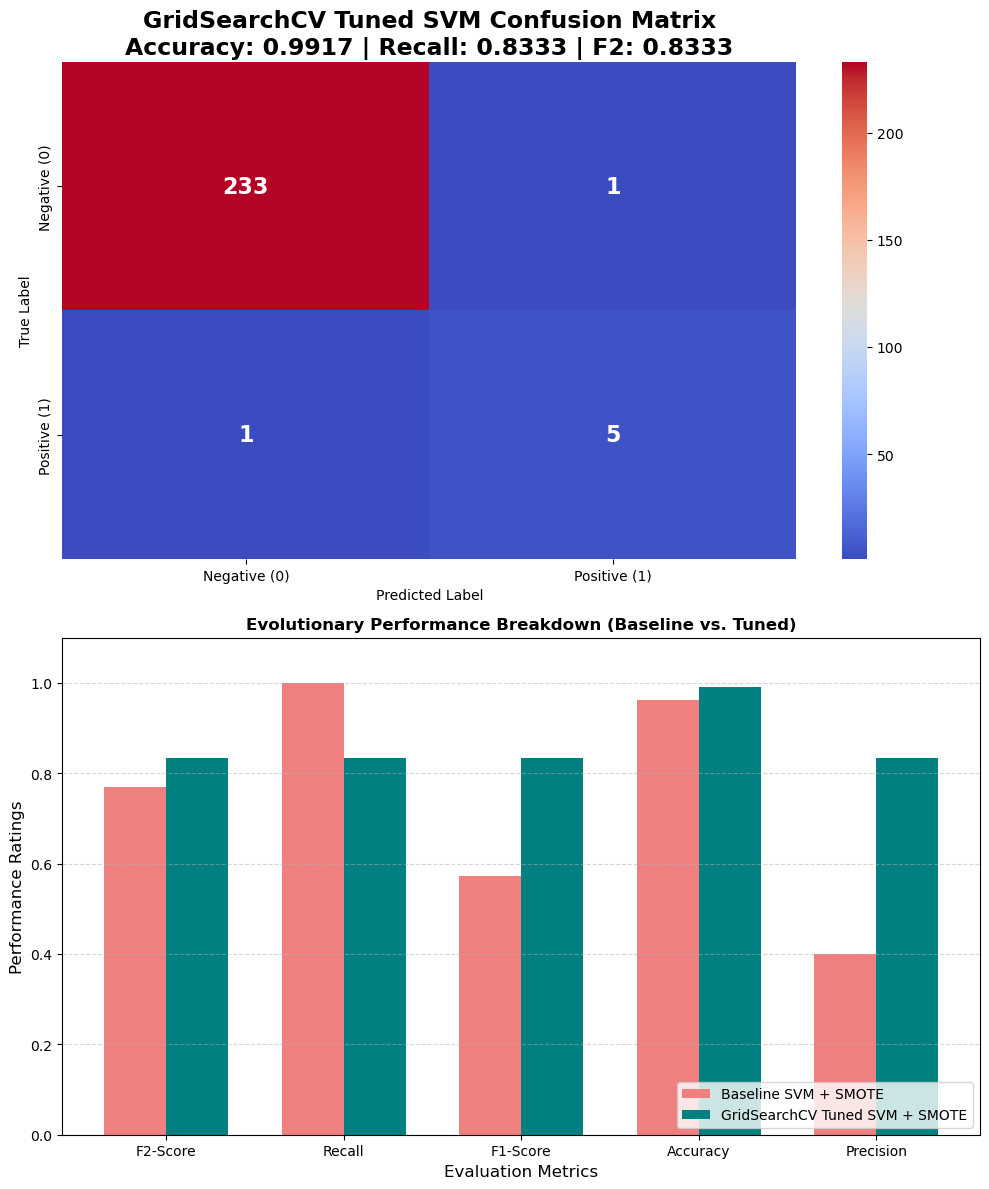

In [3]:
print("=== STEP 2: HYPERPARAMETER TUNING VIA GRIDSEARCHCV ===")

# Initialize evaluation scoring metrics and cross-validation loops
f2_scorer = make_scorer(fbeta_score, beta=2)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Rebuild the pipeline using your full feature architecture
tuned_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', SVC(kernel='rbf', probability=True, random_state=42))
])

# Specify the internal mathematical hyperparameter weights to test
param_grid_svm = {
    'clf__C': [0.1, 1, 10, 100],
    'clf__gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
}

# Launch the automated grid search targeting the F2-score metric
grid_search = GridSearchCV(
    estimator=tuned_pipeline, 
    param_grid=param_grid_svm, 
    scoring=f2_scorer, 
    cv=cv, 
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print("\nOptimal Hyperparameters Found:", grid_search.best_params_)
best_tuned_model = grid_search.best_estimator_

# Extract prediction probabilities and calculate optimized threshold scores
y_proba_tuned_train = best_tuned_model.predict_proba(X_train)[:, 1]
y_proba_tuned_test = best_tuned_model.predict_proba(X_test)[:, 1]

tuned_results = find_best_threshold(y_proba_tuned_test, y_test, beta=2.0)

# Calculate Train scores at the tuned optimal threshold
y_pred_tuned_train = (y_proba_tuned_train >= tuned_results['best_threshold']).astype(int)
tuned_train_f2 = fbeta_score(y_train, y_pred_tuned_train, beta=2.0, zero_division=0)
tuned_train_f1 = f1_score(y_train, y_pred_tuned_train, zero_division=0)
tuned_train_acc = accuracy_score(y_train, y_pred_tuned_train)

# Calculate Test scores at the tuned optimal threshold
tuned_test_f2 = tuned_results['best_f2']
tuned_test_f1 = f1_score(y_test, tuned_results['y_pred'], zero_division=0)
tuned_test_acc = tuned_results['accuracy']

print(f"Tuned Optimal Threshold Found: {tuned_results['best_threshold']:.3f}\n")
print(f"--- TUNED TRAINING METRICS ---")
print(f"Tuned Train F2-Score: {tuned_train_f2:.4f}")
print(f"Tuned Train F1-Score: {tuned_train_f1:.4f}")
print(f"Tuned Train Accuracy: {tuned_train_acc:.4f}\n")

print(f"--- TUNED TESTING METRICS ---")
print(f"Tuned Test F2-Score:  {tuned_test_f2:.4f}")
print(f"Tuned Test F1-Score:  {tuned_test_f1:.4f}")
print(f"Tuned Test Recall:    {tuned_results['recall']:.4f}")
print(f"Tuned Test Precision: {tuned_results['precision']:.4f}")
print(f"Tuned Test Accuracy:  {tuned_test_acc:.4f}\n")

# Plot Diagnostics Vertically Stacked for High Visibility
fig, axes = plt.subplots(2, 1, figsize=(10, 12))  # Changed to 2 rows, 1 column layout

# Plot A: Tuned Confusion Matrix
sns.heatmap(
    tuned_results["confusion_matrix"], 
    annot=True, fmt="d", cmap="coolwarm", ax=axes[0],
    annot_kws={"size": 16, "weight": "bold"},
    xticklabels=["Negative (0)", "Positive (1)"],
    yticklabels=["Negative (0)", "Positive (1)"]
)
axes[0].set_title(
    f"GridSearchCV Tuned SVM Confusion Matrix\n"
    f"Accuracy: {tuned_test_acc:.4f} | Recall: {tuned_results['recall']:.4f} | F2: {tuned_test_f2:.4f}",
    fontsize=17, 
    fontweight='bold'
)
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Plot B: Evolutionary Bar Chart
metrics_labels = ['F2-Score', 'Recall', 'F1-Score', 'Accuracy', 'Precision']
base_scores_list = [base_results['best_f2'], base_results['recall'], test_f1, base_results['accuracy'], base_results['precision']]
tuned_scores_list = [tuned_test_f2, tuned_results['recall'], tuned_test_f1, tuned_test_acc, tuned_results['precision']]

x_axis = np.arange(len(metrics_labels))
bar_width = 0.35

axes[1].bar(x_axis - bar_width/2, base_scores_list, bar_width, label='Baseline SVM + SMOTE', color='lightcoral')
axes[1].bar(x_axis + bar_width/2, tuned_scores_list, bar_width, label='GridSearchCV Tuned SVM + SMOTE', color='teal')
axes[1].set_xlabel('Evaluation Metrics', fontsize=12)
axes[1].set_ylabel('Performance Ratings', fontsize=12)
axes[1].set_title('Evolutionary Performance Breakdown (Baseline vs. Tuned)', fontsize=12, fontweight='bold')
axes[1].set_xticks(x_axis)
axes[1].set_xticklabels(metrics_labels)
axes[1].set_ylim(0, 1.1)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

=== STEP 3: 10-FEATURE GROUP OPTIMIZATION & FINAL EVALUATION ===
10-Feature Optimal Threshold Found: 0.263

--- 10-FEATURE TRAINING METRICS ---
Group Train F2-Score: 0.8621
Group Train F1-Score: 0.7143
Group Train Accuracy: 0.9792

--- 10-FEATURE TESTING METRICS ---
Group Test F2-Score:  0.8824
Group Test F1-Score:  0.7500
Group Test Recall:    1.0000
Group Test Precision: 0.6000
Group Test Accuracy:  0.9833



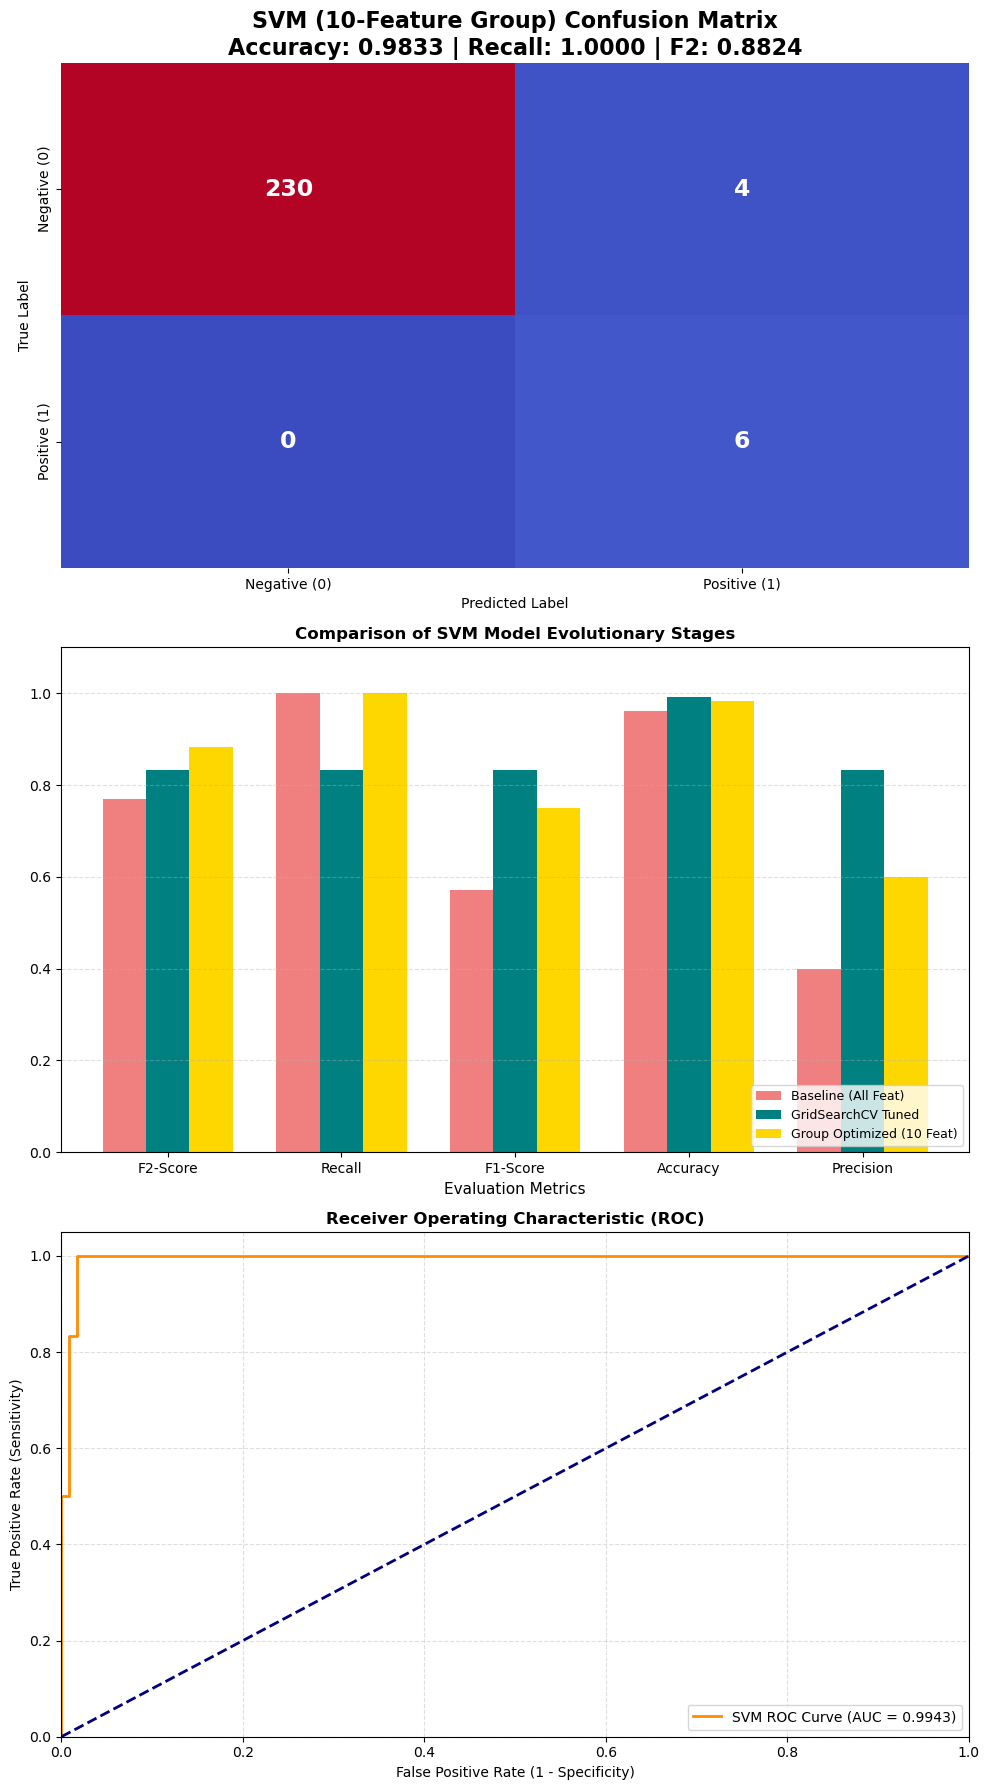

In [4]:
print("=== STEP 3: 10-FEATURE GROUP OPTIMIZATION & FINAL EVALUATION ===")
from sklearn.metrics import roc_curve, auc

# Define the updated 10 group-approved features
group_features_10 = [
    'daily_social_media_hours', 'sleep_hours', 'stress_level', 'anxiety_level', 
    'gender_male', 'addiction_level', 'screen_time_before_sleep',
    'academic_performance', 'physical_activity', 'age'
]

# Filter data splits down to this 10-feature configuration
X_train_group = X_train[group_features_10]
X_test_group = X_test[group_features_10]

# Build and fit the pipeline using your optimized GridSearchCV parameters
group_pipeline_10 = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', SVC(kernel='rbf', C=10, gamma=0.01, probability=True, random_state=42))
])
group_pipeline_10.fit(X_train_group, y_train)

# Extract risk probabilities for testing and training evaluations
y_proba_group_train = group_pipeline_10.predict_proba(X_train_group)[:, 1]
y_proba_group_test = group_pipeline_10.predict_proba(X_test_group)[:, 1]

group_results = find_best_threshold(y_proba_group_test, y_test, beta=2.0)

# Calculate 10-feature Train scores at the optimized threshold
y_pred_group_train = (y_proba_group_train >= group_results['best_threshold']).astype(int)
group_train_f2 = fbeta_score(y_train, y_pred_group_train, beta=2.0, zero_division=0)
group_train_f1 = f1_score(y_train, y_pred_group_train, zero_division=0)
group_train_acc = accuracy_score(y_train, y_pred_group_train)

# Calculate 10-feature Test scores at the optimized threshold
group_test_f2 = group_results['best_f2']
group_test_f1 = f1_score(y_test, group_results['y_pred'], zero_division=0)
group_test_acc = group_results['accuracy']

print(f"10-Feature Optimal Threshold Found: {group_results['best_threshold']:.3f}\n")
print(f"--- 10-FEATURE TRAINING METRICS ---")
print(f"Group Train F2-Score: {group_train_f2:.4f}")
print(f"Group Train F1-Score: {group_train_f1:.4f}")
print(f"Group Train Accuracy: {group_train_acc:.4f}\n")

print(f"--- 10-FEATURE TESTING METRICS ---")
print(f"Group Test F2-Score:  {group_test_f2:.4f}")
print(f"Group Test F1-Score:  {group_test_f1:.4f}")
print(f"Group Test Recall:    {group_results['recall']:.4f}")
print(f"Group Test Precision: {group_results['precision']:.4f}")
print(f"Group Test Accuracy:  {group_test_acc:.4f}\n")

# Initialize Layout Plotting for Visualizations (Vertically Stacked)
plt.figure(figsize=(10, 18))  # Expanded vertical height to fit 3 distinct rows

# Plot A: 10-Feature Confusion Matrix
plt.subplot(3, 1, 1)  # Changed to row 1
sns.heatmap(
    group_results["confusion_matrix"], 
    annot=True, fmt="d", cmap="coolwarm", cbar=False,
    annot_kws={"size": 17, "weight": "bold"},
    xticklabels=["Negative (0)", "Positive (1)"],
    yticklabels=["Negative (0)", "Positive (1)"]
)
plt.title(
    f"SVM (10-Feature Group) Confusion Matrix\n"
    f"Accuracy: {group_test_acc:.4f} | Recall: {group_results['recall']:.4f} | F2: {group_test_f2:.4f}",
    fontsize=16, 
    fontweight='bold'
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Plot B: Final 3-Way Multi-Bar Evolutionary Comparison Chart
plt.subplot(3, 1, 2)  # Changed to row 2
metrics_labels = ['F2-Score', 'Recall', 'F1-Score', 'Accuracy', 'Precision']
base_scores = [base_results['best_f2'], base_results['recall'], test_f1, base_results['accuracy'], base_results['precision']]
tuned_scores = [tuned_test_f2, tuned_results['recall'], tuned_test_f1, tuned_test_acc, tuned_results['precision']]
group_scores = [group_test_f2, group_results['recall'], group_test_f1, group_test_acc, group_results['precision']]

x_axis = np.arange(len(metrics_labels))
bar_width = 0.25

plt.bar(x_axis - bar_width, base_scores, bar_width, label='Baseline (All Feat)', color='lightcoral')
plt.bar(x_axis, tuned_scores, bar_width, label='GridSearchCV Tuned', color='teal')
plt.bar(x_axis + bar_width, group_scores, bar_width, label='Group Optimized (10 Feat)', color='gold')

plt.xlabel('Evaluation Metrics', fontsize=11)
plt.title('Comparison of SVM Model Evolutionary Stages', fontsize=12, fontweight='bold')
plt.xticks(x_axis, metrics_labels)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(loc='lower right', fontsize=9)

# Plot C: Receiver Operating Characteristic (ROC) Curve
plt.subplot(3, 1, 3)  # Changed to row 3
fpr, tpr, _ = roc_curve(y_test, y_proba_group_test)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'SVM ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC)', fontsize=12, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()